# Question 1

## a)

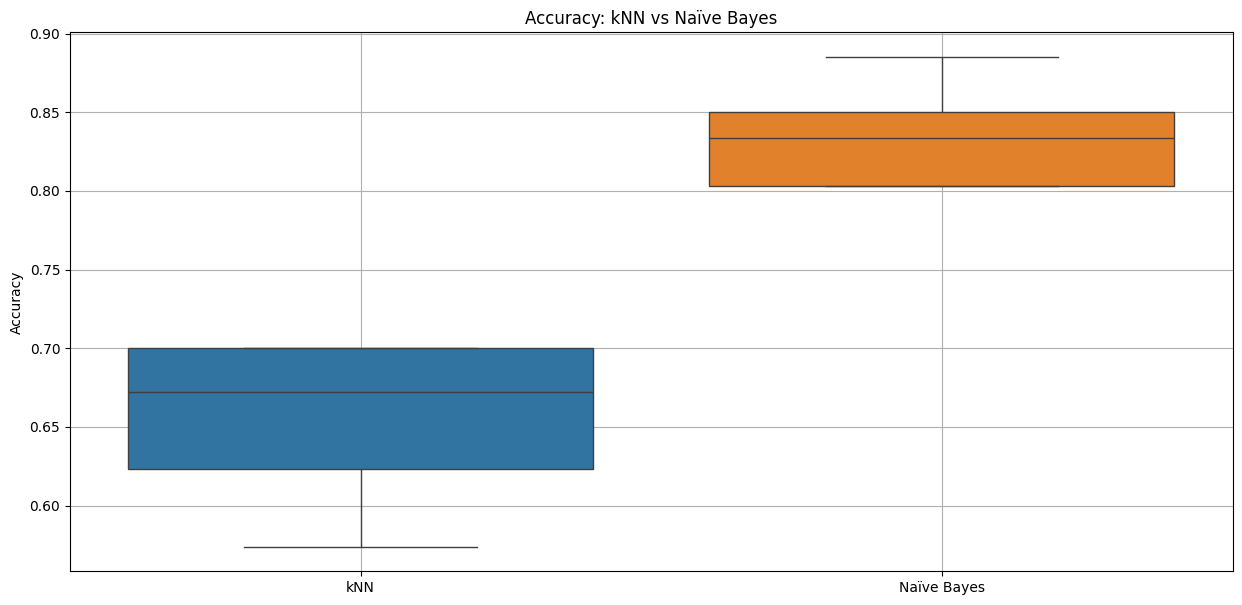

In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

df = pd.read_csv("heart-disease.csv")
X = df.drop(columns='target')
y = df['target']

folds = StratifiedKFold(n_splits=5, shuffle=True,random_state=0)
knn = KNeighborsClassifier(n_neighbors=5)
nb = GaussianNB()

knn_acc = cross_val_score(knn, X, y, cv = folds, scoring='accuracy')
nb_acc = cross_val_score(nb, X, y, cv = folds, scoring='accuracy')

df_plotting = pd.DataFrame({
    'kNN': knn_acc,
    'Naïve Bayes': nb_acc
})

# Plotting
plt.figure(figsize=(15, 7))
sns.boxplot(data=df_plotting)
plt.title('Accuracy: kNN vs Naïve Bayes')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

O modelo Naïve Bayes é mais estável visto que apresenta uma menor variação de accuracy. Isto deve-se, em parte, ao facto do kNN estar mais exposto a pequenas mudanças nos neighbours entre diferentes folds enquanto o Naïve Bayes generaliza melhor com o uso de probabilidades.

## b)

In [45]:
from sklearn.preprocessing import MinMaxScaler
from scipy import stats

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

knn_scaled_acc = cross_val_score(knn, X_scaled, y, cv=folds, scoring='accuracy')
nb_scaled_acc = cross_val_score(nb, X_scaled, y, cv=folds, scoring='accuracy')

print(knn_scaled_acc)
print(nb_scaled_acc)

[0.83606557 0.80327869 0.85245902 0.83333333 0.78333333]
[0.8852459  0.80327869 0.80327869 0.85       0.83333333]


Aplicar o scaler aos modelos tem resultados diferentes. No modelo kNN, escalar os dados permite ter a certeza que variáveis com distâncias maiores não enviesam os dados, atribuindo um valor limitado de 0 a 1 de forma a suavizar a sua influência nos outros dados. No modelo Naïve Bayes, escalar os dados não muda a performance pois o modelo baseia-se em probabilidades que não são afetadas pelo scaling.

## c)

In [20]:
res = stats.ttest_rel(knn_scaled_acc, nb_scaled_acc, alternative='greater')
print(res.pvalue)

0.7462688051215336


Dado o valor do resultado (p-value ≃ 0.75), para valores normais de significância (1%, 5% e 10%), aceita-se a hipótese nula (0) e rejeita-se a hipótese 1 que dita que há melhoria na accuracy do kNN comparado com o Naïve Bayes. Logo, não se pode afirmar que há maior accuracy. No entanto, não é correto afirmar que há uma pior ou igual accuracy pois não se pode considerar a hipótese falsa sem mais informação.

# Question 2

## a)

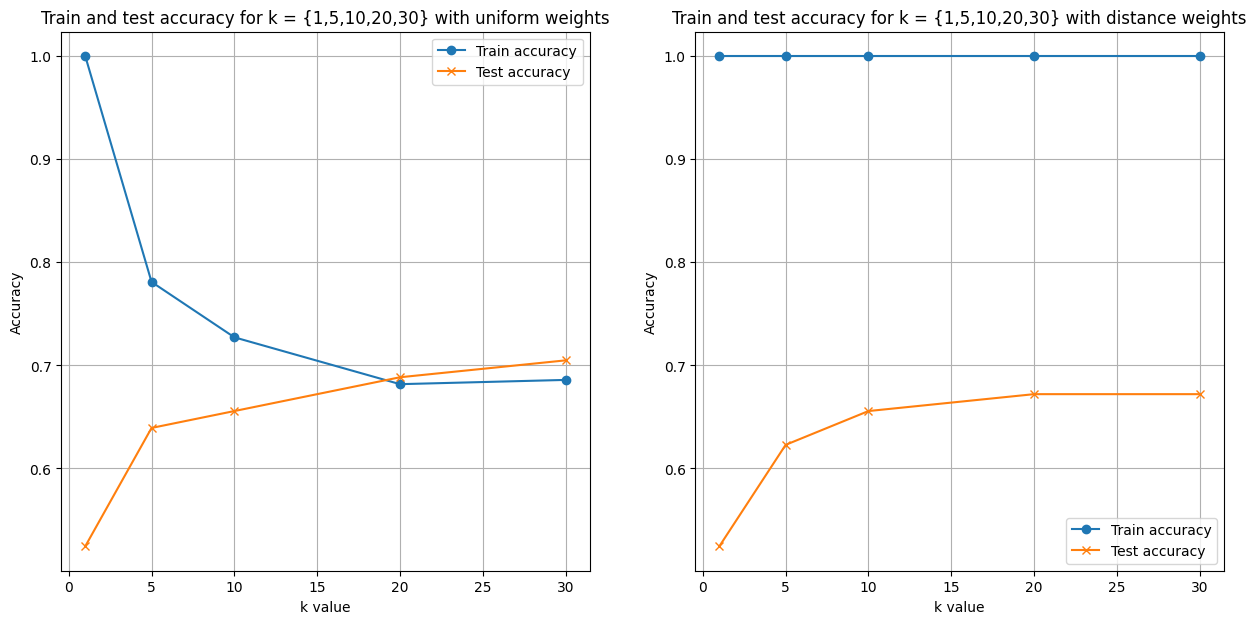

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

k_values = [1, 5, 10, 20, 30]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

uniform_train_accs = []
uniform_test_accs = []
distance_train_accs = []
distance_test_accs = []

for k in k_values:
    knn_uniform = KNeighborsClassifier(n_neighbors=k, weights='uniform')
    knn_distance = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn_uniform.fit(X_train, y_train)
    knn_distance.fit(X_train, y_train)
    uniform_train_accs.append(knn_uniform.score(X_train,y_train))
    uniform_test_accs.append(knn_uniform.score(X_test, y_test))
    distance_train_accs.append(knn_distance.score(X_train,y_train))
    distance_test_accs.append(knn_distance.score(X_test, y_test))

# Plotting
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.plot(k_values, uniform_train_accs, marker='o', label='Train accuracy')
plt.plot(k_values, uniform_test_accs, marker='x', label='Test accuracy')
plt.title('Train and test accuracy for k = {1,5,10,20,30} with uniform weights')
plt.xlabel('k value')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_values, distance_train_accs, marker='o', label='Train accuracy')
plt.plot(k_values, distance_test_accs, marker='x', label='Test accuracy')
plt.title('Train and test accuracy for k = {1,5,10,20,30} with distance weights')
plt.xlabel('k value')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

## b)

À medida que o valor do k aumenta podemos ver várias tendências em ambos modelos. No modelo com o peso uniforme, quando o k é pequeno, há tendência a overfitting por considerar muito poucos vizinhos, assim a training accuracy é alta (até 100% no caso de k=1, pois apenas se limita a memorizar os dados) mas a test accuracy é baixa devido à dificuldade de classificar novas observações do modelo. Quando o k aumenta, a training accuracy diminui e a test accuracy aumenta pois o modelo considera mais neighbours reduzindo assim a tendência para o overfitting e aumentando a capacidade de generalização. Quando o k é muito elevado, a accuracy não aumenta tanto pois começa a generalizar mais até atingir um ponto perto de perfect fit mas sem ter uma accuracy ótima devido também à generalização que não o permite reconhecer observações mais diferentes. No modelo com o peso por distância, o mesmo acontece para a test accuracy pelas mesmas razões, no entanto, a train accuracy é sempre 100% pois os valores do k são pequenos o suficiente para garantir que são sempre escolhidos no treino os neighbours com a menor distância.

# Question 3

As duas maiores dificuldades do modelo estão relacionadas com as assunções do Naïve Bayes sobre os dados, isto é, que os dados são independentes e que seguem uma distribuição gaussiana. Devido à natureza dos dados, é fácil reparar que algumas variáveis dependem de outras, por exemplo, o nível de colestrol e a pressão sanguínea. Sendo verdade que em alguns casos não faz diferença, pode prejudicar o desempenho do modelo. Além disso, dados categóricos, como o sexo, não seguem distribuições gaussianas causando assim biases ao calcular as probabilidades para o modelo.